In [3]:
#@title 0) setup

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# 1) GPT-2 Small From Scratch

### 1.1) Configuration

In [4]:
vocab_size = 50257
context_length = 1024
hidden_dimension = 768
number_of_heads = 12
number_of_layers = 12
feedforward_dimension = hidden_dimension * 4
dropout_rate = 0.1

### 1.2) Token Embedding + Positional Encoding

In [5]:
class ScratchTokenAndPositionEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, hidden_dimension)
        self.position_embedding = nn.Embedding(context_length, hidden_dimension)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        token_embeddings = self.token_embedding(token_ids)
        positions = torch.arange(sequence_length, device=token_ids.device)
        position_embeddings = self.position_embedding(positions)
        return self.dropout(token_embeddings + position_embeddings)


### 1.3) Layer Normalization

In [6]:
class ScratchLayerNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.gain = nn.Parameter(torch.ones(hidden_dimension))
        self.bias = nn.Parameter(torch.zeros(hidden_dimension))
        self.epsilon = 1e-5

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x - mean) / torch.sqrt(variance + self.epsilon)
        return self.gain * normalized + self.bias


### 1.4) GELU Activation

In [7]:
class ScratchGELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * x.pow(3))
        ))


### 1.5) Causal Multi-Head Attention

In [8]:
class ScratchCausalMultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.head_dimension = hidden_dimension // number_of_heads

        self.query_projection = nn.Linear(hidden_dimension, hidden_dimension)
        self.key_projection = nn.Linear(hidden_dimension, hidden_dimension)
        self.value_projection = nn.Linear(hidden_dimension, hidden_dimension)
        self.output_projection = nn.Linear(hidden_dimension, hidden_dimension)
        self.attention_dropout = nn.Dropout(dropout_rate)
        self.output_dropout = nn.Dropout(dropout_rate)

        self.register_buffer(
            "causal_mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1).bool()
        )

    def forward(self, x):
        batch_size, sequence_length, _ = x.shape

        queries = self.query_projection(x).view(batch_size, sequence_length, number_of_heads, self.head_dimension).transpose(1, 2)
        keys = self.key_projection(x).view(batch_size, sequence_length, number_of_heads, self.head_dimension).transpose(1, 2)
        values = self.value_projection(x).view(batch_size, sequence_length, number_of_heads, self.head_dimension).transpose(1, 2)

        attention_scores = (queries @ keys.transpose(-2, -1)) / math.sqrt(self.head_dimension)
        attention_scores = attention_scores.masked_fill(
            self.causal_mask[:sequence_length, :sequence_length], float("-inf")
        )
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)

        attention_output = (attention_weights @ values).transpose(1, 2).contiguous().view(batch_size, sequence_length, hidden_dimension)
        return self.output_dropout(self.output_projection(attention_output))


### 1.6) Feed-Forward Network

In [9]:
class ScratchFeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.expand_linear = nn.Linear(hidden_dimension, feedforward_dimension)
        self.contract_linear = nn.Linear(feedforward_dimension, hidden_dimension)
        self.activation = ScratchGELU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.expand_linear(x)
        x = self.activation(x)
        x = self.contract_linear(x)
        return self.dropout(x)


### 1.7) Transformer Block

In [10]:
class ScratchTransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.first_layer_norm = ScratchLayerNorm()
        self.attention = ScratchCausalMultiHeadAttention()
        self.second_layer_norm = ScratchLayerNorm()
        self.feed_forward = ScratchFeedForward()

    def forward(self, x):
        x = x + self.attention(self.first_layer_norm(x))
        x = x + self.feed_forward(self.second_layer_norm(x))
        return x


### 1.8) GPT-2 Model

In [11]:
class ScratchGPT2(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = ScratchTokenAndPositionEmbedding()
        self.transformer_blocks = nn.ModuleList(
            [ScratchTransformerBlock() for _ in range(number_of_layers)])
        self.final_layer_norm = ScratchLayerNorm()
        self.unembedding = nn.Linear(hidden_dimension, vocab_size, bias=False)
        self.unembedding.weight = self.embedding.token_embedding.weight

    def forward(self, token_ids):
        x = self.embedding(token_ids)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.final_layer_norm(x)
        logits = self.unembedding(x)
        return logits


### 1.9) Forward Pass

In [12]:
scratch_model = ScratchGPT2()
scratch_model.eval()

total_parameters = sum(p.numel() for p in scratch_model.parameters())
print(f"Total parameters: {total_parameters:,}")

sample_input = torch.randint(0, vocab_size, (1, 16))
with torch.no_grad():
    logits = scratch_model(sample_input)
print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {logits.shape}")


Total parameters: 124,439,808
Input shape:  torch.Size([1, 16])
Output shape: torch.Size([1, 16, 50257])


# 2) GPT-2 Small, PyTorch Components

### 2.1) Configuration

In [13]:
vocab_size = 50257
context_length = 1024
hidden_dimension = 768
number_of_heads = 12
number_of_layers = 12
feedforward_dimension = hidden_dimension * 4
dropout_rate = 0.1


### 2.2) Causal Multi-Head Attention

In [14]:
class PyTorchCausalMultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dimension,
            num_heads=number_of_heads,
            dropout=dropout_rate,
            batch_first=True,
        )
        self.register_buffer(
            "causal_mask",
            nn.Transformer.generate_square_subsequent_mask(context_length)
        )

    def forward(self, x):
        sequence_length = x.shape[1]
        mask = self.causal_mask[:sequence_length, :sequence_length]
        output, _ = self.attention(x, x, x, attn_mask=mask, is_causal=True)
        return output


### 2.3) Feed-Forward Network

In [15]:
class PyTorchFeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(hidden_dimension, feedforward_dimension),
            nn.GELU(approximate="tanh"),
            nn.Linear(feedforward_dimension, hidden_dimension),
            nn.Dropout(dropout_rate),
        )

    def forward(self, x):
        return self.network(x)


### 2.4) Transformer Block

In [16]:
class PyTorchTransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.first_layer_norm = nn.LayerNorm(hidden_dimension)
        self.attention = PyTorchCausalMultiHeadAttention()
        self.second_layer_norm = nn.LayerNorm(hidden_dimension)
        self.feed_forward = PyTorchFeedForward()

    def forward(self, x):
        x = x + self.attention(self.first_layer_norm(x))
        x = x + self.feed_forward(self.second_layer_norm(x))
        return x


### 2.5) GPT-2 Model

In [17]:
class PyTorchGPT2(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, hidden_dimension)
        self.position_embedding = nn.Embedding(context_length, hidden_dimension)
        self.dropout = nn.Dropout(dropout_rate)
        self.transformer_blocks = nn.ModuleList([PyTorchTransformerBlock() for _ in range(number_of_layers)])
        self.final_layer_norm = nn.LayerNorm(hidden_dimension)
        self.unembedding = nn.Linear(hidden_dimension, vocab_size, bias=False)
        self.unembedding.weight = self.token_embedding.weight

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        positions = torch.arange(sequence_length, device=token_ids.device)
        x = self.dropout(self.token_embedding(token_ids) + self.position_embedding(positions))
        for block in self.transformer_blocks:
            x = block(x)
        x = self.final_layer_norm(x)
        return self.unembedding(x)


### 2.6) Forward Pass

In [18]:
pytorch_model = PyTorchGPT2()
pytorch_model.eval()

total_parameters = sum(p.numel() for p in pytorch_model.parameters())
print(f"Total parameters: {total_parameters:,}")

sample_input = torch.randint(0, vocab_size, (1, 16))
with torch.no_grad():
    logits = pytorch_model(sample_input)
print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {logits.shape}")


Total parameters: 124,439,808
Input shape:  torch.Size([1, 16])
Output shape: torch.Size([1, 16, 50257])


# 3) NanoGPT (Karpathy)

### 3.1) Configuration

In [19]:
from dataclasses import dataclass

@dataclass
class NanoGPTConfig:
    vocab_size: int = 50257
    context_length: int = 1024
    hidden_dimension: int = 768
    number_of_heads: int = 12
    number_of_layers: int = 12
    feedforward_dimension: int = 768 * 4
    dropout_rate: float = 0.1
    bias: bool = True

nano_config = NanoGPTConfig()


### 3.2) Causal Multi-Head Attention

In [20]:
class NanoGPTCausalMultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.number_of_heads = config.number_of_heads
        self.hidden_dimension = config.hidden_dimension
        self.head_dimension = config.hidden_dimension // config.number_of_heads
        self.query_key_value_projection = nn.Linear(config.hidden_dimension, 3 * config.hidden_dimension, bias=config.bias)
        self.output_projection = nn.Linear(config.hidden_dimension, config.hidden_dimension, bias=config.bias)
        self.residual_dropout = nn.Dropout(config.dropout_rate)

    def forward(self, x):
        batch_size, sequence_length, _ = x.shape
        query, key, value = self.query_key_value_projection(x).split(self.hidden_dimension, dim=2)
        query = query.view(batch_size, sequence_length, self.number_of_heads, self.head_dimension).transpose(1, 2)
        key = key.view(batch_size, sequence_length, self.number_of_heads, self.head_dimension).transpose(1, 2)
        value = value.view(batch_size, sequence_length, self.number_of_heads, self.head_dimension).transpose(1, 2)
        attention_output = F.scaled_dot_product_attention(
            query, key, value, attn_mask=None,
            dropout_p=self.residual_dropout.p if self.training else 0,
            is_causal=True
        )
        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, sequence_length, self.hidden_dimension)
        return self.residual_dropout(self.output_projection(attention_output))


### 3.3) Feed-Forward Network

In [21]:
class NanoGPTFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.expand_linear = nn.Linear(config.hidden_dimension, config.feedforward_dimension, bias=config.bias)
        self.contract_linear = nn.Linear(config.feedforward_dimension, config.hidden_dimension, bias=config.bias)
        self.activation = nn.GELU(approximate='tanh')
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, x):
        return self.dropout(self.contract_linear(self.activation(self.expand_linear(x))))


### 3.4) Transformer Block

In [22]:
class NanoGPTTransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.first_layer_norm = nn.LayerNorm(config.hidden_dimension, bias=config.bias)
        self.attention = NanoGPTCausalMultiHeadAttention(config)
        self.second_layer_norm = nn.LayerNorm(config.hidden_dimension, bias=config.bias)
        self.feed_forward = NanoGPTFeedForward(config)

    def forward(self, x):
        x = x + self.attention(self.first_layer_norm(x))
        x = x + self.feed_forward(self.second_layer_norm(x))
        return x


### 3.5) GPT-2 Model

In [23]:
class NanoGPT2(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            token_embedding=nn.Embedding(config.vocab_size, config.hidden_dimension),
            position_embedding=nn.Embedding(config.context_length, config.hidden_dimension),
            dropout=nn.Dropout(config.dropout_rate),
            blocks=nn.ModuleList([NanoGPTTransformerBlock(config) for _ in range(config.number_of_layers)]),
            final_layer_norm=nn.LayerNorm(config.hidden_dimension, bias=config.bias),
        ))
        self.unembedding = nn.Linear(config.hidden_dimension, config.vocab_size, bias=False)
        self.unembedding.weight = self.transformer.token_embedding.weight

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        positions = torch.arange(sequence_length, device=token_ids.device)
        x = self.transformer.dropout(
            self.transformer.token_embedding(token_ids) + self.transformer.position_embedding(positions)
        )
        for block in self.transformer.blocks:
            x = block(x)
        x = self.transformer.final_layer_norm(x)
        return self.unembedding(x)


### 3.6) Forward Pass

In [24]:
nano_model = NanoGPT2(nano_config)
nano_model.eval()

total_parameters = sum(p.numel() for p in nano_model.parameters())
print(f"Total parameters: {total_parameters:,}")

sample_input = torch.randint(0, nano_config.vocab_size, (1, 16))
with torch.no_grad():
    logits = nano_model(sample_input)
print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {logits.shape}")


Total parameters: 124,439,808
Input shape:  torch.Size([1, 16])
Output shape: torch.Size([1, 16, 50257])


# 4) x-transformers (lucidrains)

### 4.1) Configuration + GPT-2 Model

In [25]:
pip install x_transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.8/99.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.4 MB/s eta 0:00:00


In [26]:
from x_transformers import TransformerWrapper, Decoder

vocab_size = 50257
context_length = 1024
hidden_dimension = 768
number_of_heads = 12
number_of_layers = 12

xt_model = TransformerWrapper(
    num_tokens=vocab_size,
    max_seq_len=context_length,
    attn_layers=Decoder(
        dim=hidden_dimension,
        depth=number_of_layers,
        heads=number_of_heads,
        attn_flash=True,
    )
)


### 4.2) Forward Pass

In [27]:
xt_model.eval()

total_parameters = sum(p.numel() for p in xt_model.parameters())
print(f"Total parameters: {total_parameters:,}")

sample_input = torch.randint(0, vocab_size, (1, 16))
with torch.no_grad():
    logits = xt_model(sample_input)
print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {logits.shape}")


Total parameters: 162,981,120
Input shape:  torch.Size([1, 16])
Output shape: torch.Size([1, 16, 50257])


# 5) TorchTune (Meta)

### 5.1) Configuration

In [28]:
from torchtune.modules import (
    TransformerDecoder,
    TransformerSelfAttentionLayer,
    MultiHeadAttention,
    FeedForward,
    RotaryPositionalEmbeddings,
)

vocab_size = 50257
context_length = 1024
hidden_dimension = 768
number_of_heads = 12
number_of_layers = 12
feedforward_dimension = hidden_dimension * 4
head_dimension = hidden_dimension // number_of_heads
dropout_rate = 0.1


### 5.2) Transformer Layer

In [29]:
def build_torchtune_layer():
    attention = MultiHeadAttention(
        embed_dim=hidden_dimension,
        num_heads=number_of_heads,
        num_kv_heads=number_of_heads,
        head_dim=head_dimension,
        q_proj=nn.Linear(hidden_dimension, hidden_dimension, bias=True),
        k_proj=nn.Linear(hidden_dimension, hidden_dimension, bias=True),
        v_proj=nn.Linear(hidden_dimension, hidden_dimension, bias=True),
        output_proj=nn.Linear(hidden_dimension, hidden_dimension, bias=True),
        pos_embeddings=RotaryPositionalEmbeddings(dim=head_dimension),
        max_seq_len=context_length,
        attn_dropout=dropout_rate,
    )
    feed_forward = FeedForward(
        gate_proj=nn.Linear(hidden_dimension, feedforward_dimension, bias=True),
        down_proj=nn.Linear(feedforward_dimension, hidden_dimension, bias=True),
        up_proj=None,
        activation=nn.GELU(approximate="tanh"),
    )
    return TransformerSelfAttentionLayer(
        attn=attention,
        mlp=feed_forward,
        sa_norm=nn.LayerNorm(hidden_dimension),
        mlp_norm=nn.LayerNorm(hidden_dimension),
    )

### 5.3) GPT-2 Model

In [30]:
tt_model = TransformerDecoder(
    tok_embeddings=nn.Embedding(vocab_size, hidden_dimension),
    layers=nn.ModuleList([build_torchtune_layer() for _ in range(number_of_layers)]),
    max_seq_len=context_length,
    num_heads=number_of_heads,
    head_dim=head_dimension,
    norm=nn.LayerNorm(hidden_dimension),
    output=nn.Linear(hidden_dimension, vocab_size, bias=False),
)


### 5.4) Forward Pass

In [31]:
tt_model.eval()

total_parameters = sum(p.numel() for p in tt_model.parameters())
print(f"Total parameters: {total_parameters:,}")

sample_input = torch.randint(0, vocab_size, (1, 16))
input_pos = torch.arange(16).unsqueeze(0)
with torch.no_grad():
    logits = tt_model(tokens=sample_input, input_pos=input_pos)
print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {logits.shape}")


Total parameters: 162,250,752
Input shape:  torch.Size([1, 16])
Output shape: torch.Size([1, 16, 50257])


# 6) LitGPT (Lightning AI)

### 6.1) Configuration + GPT-2 Model

In [32]:
!pip install litgpt lightning lightning-utilities torchmetrics pytorch-lightning --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 9.3 MB/s eta 0:00:00


In [48]:
from litgpt import GPT, Config

# Manually define the GPT-2 Small configuration
lit_config = Config(
    name="gpt2",
    block_size=1024,
    vocab_size=50257,
    padding_multiple=1,
    n_layer=12,
    n_head=12,
    n_embd=768,
    bias=True,
    lm_head_bias=False,
    norm_class_name="LayerNorm",
    mlp_class_name="GptNeoxMLP",
    intermediate_size=3072,
    rotary_percentage=0.0,
)
lit_model = GPT(lit_config)

# Tie the weights of the LM head to the token embeddings (Standard GPT-2 behavior)
lit_model.lm_head.weight = lit_model.transformer.wte.weight



### 6.2) Forward Pass

In [49]:
lit_model.eval()

total_parameters = sum(p.numel() for p in lit_model.parameters())
print(f"Total parameters: {total_parameters:,}")

sample_input = torch.randint(0, lit_config.padded_vocab_size, (1, 16))
with torch.no_grad():
    logits = lit_model(sample_input)
print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {logits.shape}")


Total parameters: 123,653,376
Input shape:  torch.Size([1, 16])
Output shape: torch.Size([1, 16, 50257])


# 7) Architecture Diagrams

In [50]:
#@title visualization

import graphviz
from IPython.display import display


def module_label(module):
    cls = module.__class__.__name__
    if isinstance(module, nn.Linear):
        bias = ", bias" if module.bias is not None else ""
        return f"{cls}({module.in_features} → {module.out_features}{bias})"
    if isinstance(module, nn.Embedding):
        return f"{cls}({module.num_embeddings}, {module.embedding_dim})"
    if isinstance(module, nn.LayerNorm):
        return f"{cls}({module.normalized_shape[0]})"
    if isinstance(module, nn.Dropout):
        return f"{cls}(p={module.p})"
    if isinstance(module, nn.MultiheadAttention):
        return f"{cls}(d={module.embed_dim}, h={module.num_heads})"
    if isinstance(module, nn.GELU):
        return f"{cls}(approx='{module.approximate}')"
    params = sum(p.numel() for p in module.parameters())
    return f"{cls} ({params:,} params)" if params else cls


def module_color(module):
    cls = type(module).__name__.lower()
    if 'embed' in cls:                                    return '#7C3AED', '#6D28D9'
    if 'norm' in cls or 'layernorm' in cls:               return '#0D9488', '#0F766E'
    if 'attention' in cls or 'attn' in cls or 'mha' in cls: return '#2563EB', '#1D4ED8'
    if 'feed' in cls or 'ffn' in cls or 'mlp' in cls:    return '#D97706', '#B45309'
    if 'dropout' in cls:                                  return '#475569', '#334155'
    if 'gelu' in cls or 'relu' in cls or 'silu' in cls:  return '#059669', '#047857'
    if 'linear' in cls:                                   return '#DB2777', '#BE185D'
    if 'identity' in cls:                                 return '#475569', '#334155'
    return '#1E293B', '#334155'


def html_node(title, detail, c_top, c_bot):
    return (
        f'<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="6">'
        f'<TR><TD BGCOLOR="{c_top}" WIDTH="260"><FONT COLOR="white" POINT-SIZE="12"><B> {title} </B></FONT></TD></TR>'
        f'<TR><TD BGCOLOR="{c_bot}" WIDTH="260"><FONT COLOR="#CBD5E1" POINT-SIZE="10"> {detail} </FONT></TD></TR>'
        f'</TABLE>>'
    )


def is_leaf(module):
    children = list(module.children())
    if not children:
        return True
    if isinstance(module, nn.Sequential) and len(children) <= 5:
        return True
    return False


def visualize_architecture(model, title):
    dot = graphviz.Digraph(format='svg')
    dot.attr(rankdir='TB', bgcolor='#0B1120', fontname='Helvetica',
             nodesep='0.5', ranksep='0.35', margin='0.2')
    dot.attr('node', shape='plaintext', fontname='Helvetica')
    dot.attr('edge', color='#64748B', arrowsize='0.7', penwidth='1.5')

    dot.node('title',
             f'<<FONT COLOR="white" POINT-SIZE="16"><B>{title}</B></FONT>>',
             shape='none')

    counter = [0]
    def nid():
        counter[0] += 1
        return f"n{counter[0]}"

    def add_leaf(graph, name, module):
        node_id = nid()
        ct, cb = module_color(module)
        graph.node(node_id, html_node(name, module_label(module), ct, cb))
        return node_id

    def walk(graph, module, prefix=''):
        ids = []
        for child_name, child in module.named_children():
            full = f"{prefix}.{child_name}" if prefix else child_name

            if isinstance(child, (nn.ModuleList,)):
                classes = [type(m).__name__ for m in child]
                if len(set(classes)) == 1 and len(child) > 1:
                    cname = f"cluster_{full.replace('.','_')}"
                    with graph.subgraph(name=cname) as c:
                        c.attr(style='rounded,dashed', color='#475569',
                               fontcolor='#F8FAFC', penwidth='2', fontsize='13',
                               label=f'  {classes[0]} × {len(child)}  ', margin='20')
                        inner = walk(c, child[0], full + '.0')
                        ids.extend(inner)
                else:
                    for i, item in enumerate(child):
                        ids.extend(walk(graph, item, f"{full}.{i}"))

            elif isinstance(child, nn.ModuleDict):
                for k, v in child.items():
                    if isinstance(v, nn.ModuleList):
                        classes = [type(m).__name__ for m in v]
                        if len(set(classes)) == 1 and len(v) > 1:
                            cname = f"cluster_{full}_{k}".replace('.','_')
                            with graph.subgraph(name=cname) as c:
                                c.attr(style='rounded,dashed', color='#475569',
                                       fontcolor='#F8FAFC', penwidth='2', fontsize='13',
                                       label=f'  {classes[0]} × {len(v)}  ', margin='20')
                                inner = walk(c, v[0], f"{full}.{k}.0")
                                ids.extend(inner)
                        else:
                            for i, item in enumerate(v):
                                ids.extend(walk(graph, item, f"{full}.{k}.{i}"))
                    elif is_leaf(v):
                        ids.append(add_leaf(graph, k, v))
                    else:
                        ids.extend(walk(graph, v, f"{full}.{k}"))

            elif is_leaf(child):
                ids.append(add_leaf(graph, child_name, child))
            else:
                ids.extend(walk(graph, child, full))

        return ids

    node_ids = walk(dot, model)

    if node_ids:
        dot.edge('title', node_ids[0], style='invis')
    for i in range(len(node_ids) - 1):
        dot.edge(node_ids[i], node_ids[i + 1])

    total = sum(p.numel() for p in model.parameters())
    pid = nid()
    dot.node(pid,
             f'<<FONT COLOR="#94A3B8" POINT-SIZE="11">Total: {total:,} parameters</FONT>>',
             shape='none')
    if node_ids:
        dot.edge(node_ids[-1], pid, style='invis')

    return dot

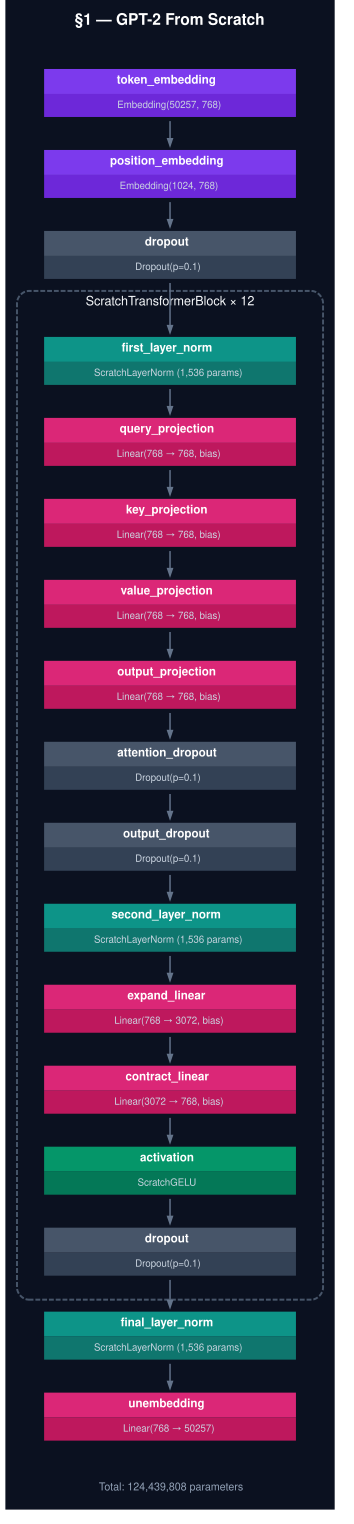

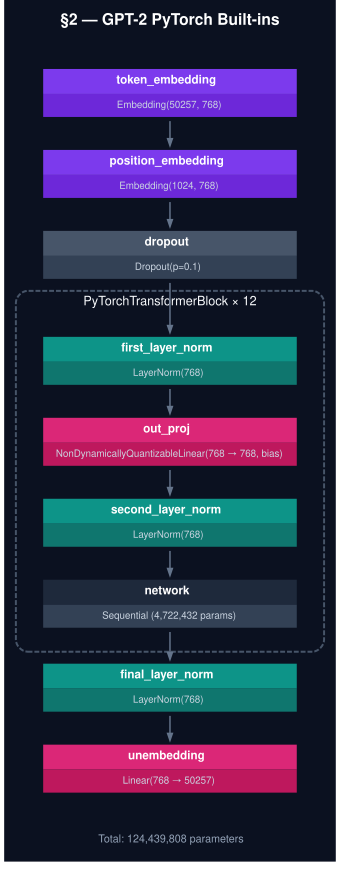

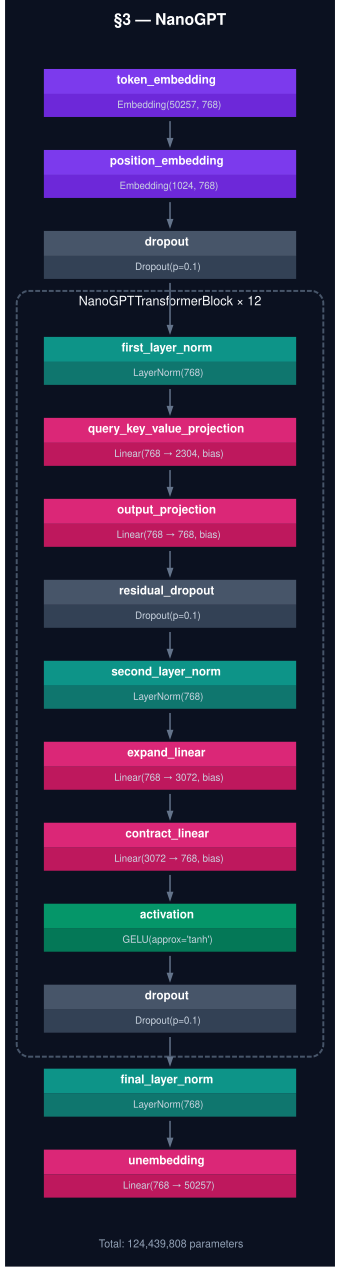

AttributeError: 'NoneType' object has no attribute 'named_children'

In [51]:
display(visualize_architecture(scratch_model, '§1 — GPT-2 From Scratch'))
display(visualize_architecture(pytorch_model, '§2 — GPT-2 PyTorch Built-ins'))
display(visualize_architecture(nano_model, '§3 — NanoGPT'))
display(visualize_architecture(xt_model, '§4 — x-transformers'))
display(visualize_architecture(tt_model, '§5 — TorchTune'))
display(visualize_architecture(lit_model, '§6 — LitGPT'))

# 8) Load Pretrained GPT-2 Weights

### 8.1) Load HuggingFace Weights into Scratch Model

In [41]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

hf_model = GPT2LMHeadModel.from_pretrained("gpt2")
hf_state = hf_model.state_dict()

def load_pretrained_weights(model):
    state = model.state_dict()

    state["embedding.token_embedding.weight"].copy_(hf_state["transformer.wte.weight"])
    state["embedding.position_embedding.weight"].copy_(hf_state["transformer.wpe.weight"])

    for layer_index in range(number_of_layers):
        hf_prefix = f"transformer.h.{layer_index}"

        state[f"transformer_blocks.{layer_index}.first_layer_norm.gain"].copy_(hf_state[f"{hf_prefix}.ln_1.weight"])
        state[f"transformer_blocks.{layer_index}.first_layer_norm.bias"].copy_(hf_state[f"{hf_prefix}.ln_1.bias"])

        qkv_weight = hf_state[f"{hf_prefix}.attn.c_attn.weight"]
        qkv_bias = hf_state[f"{hf_prefix}.attn.c_attn.bias"]
        q_weight, k_weight, v_weight = qkv_weight.split(hidden_dimension, dim=1)
        q_bias, k_bias, v_bias = qkv_bias.split(hidden_dimension, dim=0)

        # GPT-2 uses Conv1D (transposed) so we transpose into standard Linear layout
        state[f"transformer_blocks.{layer_index}.attention.query_projection.weight"].copy_(q_weight.t())
        state[f"transformer_blocks.{layer_index}.attention.query_projection.bias"].copy_(q_bias)
        state[f"transformer_blocks.{layer_index}.attention.key_projection.weight"].copy_(k_weight.t())
        state[f"transformer_blocks.{layer_index}.attention.key_projection.bias"].copy_(k_bias)
        state[f"transformer_blocks.{layer_index}.attention.value_projection.weight"].copy_(v_weight.t())
        state[f"transformer_blocks.{layer_index}.attention.value_projection.bias"].copy_(v_bias)

        state[f"transformer_blocks.{layer_index}.attention.output_projection.weight"].copy_(hf_state[f"{hf_prefix}.attn.c_proj.weight"].t())
        state[f"transformer_blocks.{layer_index}.attention.output_projection.bias"].copy_(hf_state[f"{hf_prefix}.attn.c_proj.bias"])

        state[f"transformer_blocks.{layer_index}.second_layer_norm.gain"].copy_(hf_state[f"{hf_prefix}.ln_2.weight"])
        state[f"transformer_blocks.{layer_index}.second_layer_norm.bias"].copy_(hf_state[f"{hf_prefix}.ln_2.bias"])

        state[f"transformer_blocks.{layer_index}.feed_forward.expand_linear.weight"].copy_(hf_state[f"{hf_prefix}.mlp.c_fc.weight"].t())
        state[f"transformer_blocks.{layer_index}.feed_forward.expand_linear.bias"].copy_(hf_state[f"{hf_prefix}.mlp.c_fc.bias"])
        state[f"transformer_blocks.{layer_index}.feed_forward.contract_linear.weight"].copy_(hf_state[f"{hf_prefix}.mlp.c_proj.weight"].t())
        state[f"transformer_blocks.{layer_index}.feed_forward.contract_linear.bias"].copy_(hf_state[f"{hf_prefix}.mlp.c_proj.bias"])

    state["final_layer_norm.gain"].copy_(hf_state["transformer.ln_f.weight"])
    state["final_layer_norm.bias"].copy_(hf_state["transformer.ln_f.bias"])

    model.load_state_dict(state)

pretrained_scratch_model = ScratchGPT2()
load_pretrained_weights(pretrained_scratch_model)
pretrained_scratch_model.eval()
print("Weights loaded successfully.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Weights loaded successfully.


### 8.2) Generate Text

In [43]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

def generate(model, prompt, max_new_tokens=40):
    token_ids = tokenizer.encode(prompt, return_tensors="pt")
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(token_ids[:, -context_length:])
        next_token_logits = logits[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        token_ids = torch.cat([token_ids, next_token], dim=1)
    return tokenizer.decode(token_ids[0])

print(generate(pretrained_scratch_model, "The meaning of life is"))


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The meaning of life is not the same as the meaning of death.

The meaning of life is not the same as the meaning of death.

The meaning of life is not the same as the meaning of death


### 8.3) Verify Against HuggingFace

In [42]:
test_input = torch.randint(0, vocab_size, (1, 32))

with torch.no_grad():
    scratch_logits = pretrained_scratch_model(test_input)
    hf_logits = hf_model(test_input).logits

max_difference = (scratch_logits - hf_logits).abs().max().item()
print(f"Max absolute difference: {max_difference:.2e}")
print(f"Outputs match: {max_difference < 1e-4}")


Max absolute difference: 8.39e-05
Outputs match: True
